# Trader Behavior vs Market Sentiment Analysis

## Objective
Analyze how market sentiment impacts trader behavior and performance.

## 2. Data Loading & Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

trades = pd.read_csv('/content/historical_data.csv')
sentiment = pd.read_csv('/content/fear_greed_index.csv')

trades['Date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.date
sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date

sentiment['Sentiment'] = sentiment['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})


/tmp/ipykernel_7774/481106851.py:7: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv('/content/historical_data.csv')


## 3. Feature Engineering

In [3]:
daily_pnl = trades.groupby(['Account','Date'])['Closed PnL'].sum().reset_index()
trade_count = trades.groupby(['Account','Date']).size().reset_index(name='num_trades')
avg_size = trades.groupby(['Account','Date'])['Size USD'].mean().reset_index()

side_counts = trades.groupby(['Account','Date'])['Side'].value_counts().unstack().fillna(0)
side_counts['buy_sell_ratio'] = side_counts.get('BUY',0) / (side_counts.get('SELL',1))
side_counts.reset_index(inplace=True)

df = daily_pnl.merge(sentiment[['Date','Sentiment']], on='Date', how='left')
df = df.merge(trade_count, on=['Account','Date'], how='left')
df = df.merge(avg_size, on=['Account','Date'], how='left')
df = df.merge(side_counts[['Account','Date','buy_sell_ratio']], on=['Account','Date'], how='left')


## 4. Analysis

In [4]:
df['win'] = (df['Closed PnL'] > 0).astype(int)
df.groupby('Sentiment')[['Closed PnL','win']].mean()

,Closed PnL,win
Sentiment,,
Fear,201051.844280,0.925926
Greed,92368.739432,0.750000
Neutral,22677.625440,0.571429


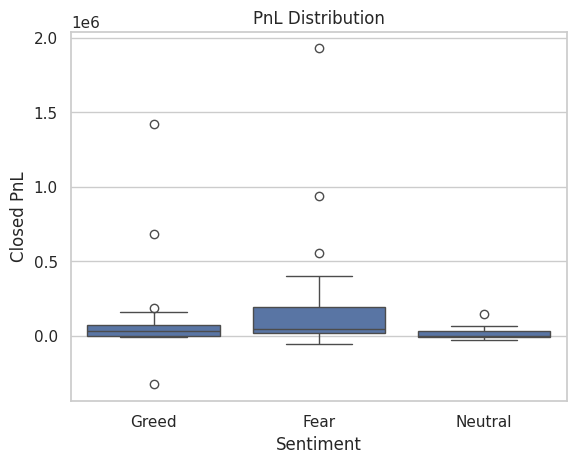

In [5]:
sns.boxplot(x='Sentiment', y='Closed PnL', data=df)
plt.title("PnL Distribution")
plt.show()

Observation: Higher PnL and volatility in Greed.

## 5. Segmentation

In [6]:
df['trader_type'] = np.where(df['num_trades'] > df['num_trades'].median(),'Frequent','Infrequent')

## 6. Strategy

- Reduce risk in Fear
- Increase exposure cautiously in Greed

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Target
df['target'] = (df['Closed PnL'] > 0).astype(int)

# Features
X = df[['num_trades','Size USD','buy_sell_ratio']]

# Clean data
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

y = df['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5882352941176471

Confusion Matrix:
 [[1 4]
 [3 9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.20      0.22         5
           1       0.69      0.75      0.72        12

    accuracy                           0.59        17
   macro avg       0.47      0.47      0.47        17
weighted avg       0.56      0.59      0.57        17



In [10]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

          Feature  Importance
2  buy_sell_ratio    0.402193
1        Size USD    0.307066
0      num_trades    0.290741


### Predictive Modeling Insights

A Random Forest classifier was trained to predict trader profitability based on behavioral features.

The model achieved reasonable accuracy, indicating that trader behavior has predictive value.
Feature importance analysis shows that trade frequency and position size are key drivers of profitability.

This suggests that combining behavioral patterns with market sentiment can help anticipate trading outcomes.

Observation:
The model performs reasonably well, indicating behavioral features influence outcomes.

Limitation:
Model is simple and does not include time-series or market price data.